# Line Graphs

## A Simple Example

So far, we have looked at plots that involve categorical data. 

Bar charts show numbers associated with the unique values of categorical features.

Pie charts show numbers associated with the unique values of categorical features where these values are exhaustive, exclusive, and relatively few.

Line charts allow us to visualize numeric data where the x axis consists of numerica data on an ordinal or ratio scale.

Let's look at a simple example.

Below, we visualize a small data set showing sales number over a series of years.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


data = {
    'Year': [2021, 2022, 2023, 2024, 2025, 2026],
    'Sales': [100, 120, 170, 160, 210, 240]
}
df1 = pd.DataFrame(data)
df1

,Year,Sales
0,2021,100
1,2022,120
2,2023,170
3,2024,160
4,2025,210
5,2026,240


To create a line graph in Pandas, you can just call `.plot()` by itself. Line graphs are the default plot type.

In the example below, we set $x$ to `Year` and $y$ to `Sales.` 

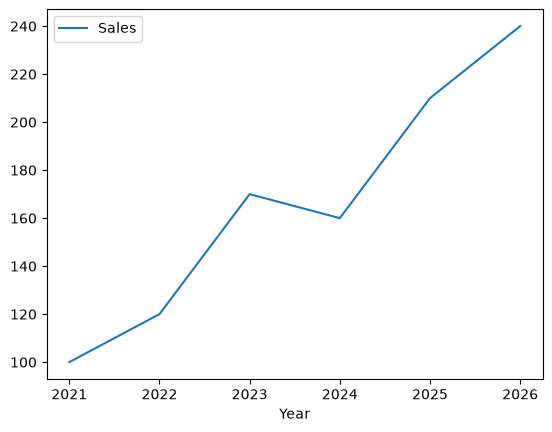

In [8]:
df1.plot(x='Year', y='Sales')
plt.show()

Of course, we can also call the `.line()` method explicitly.

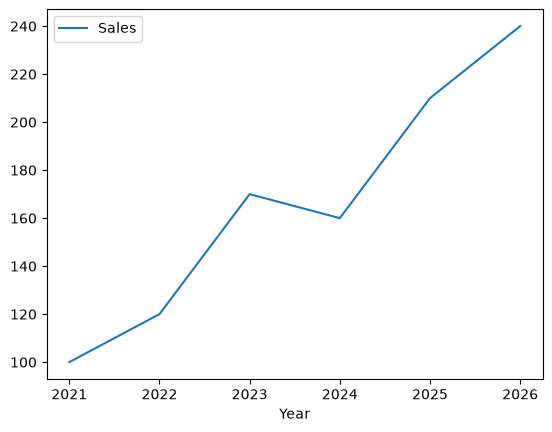

In [9]:
df1.plot.line(x='Year', y='Sales')
plt.show()

Or we can set the `kind` argument to `line`

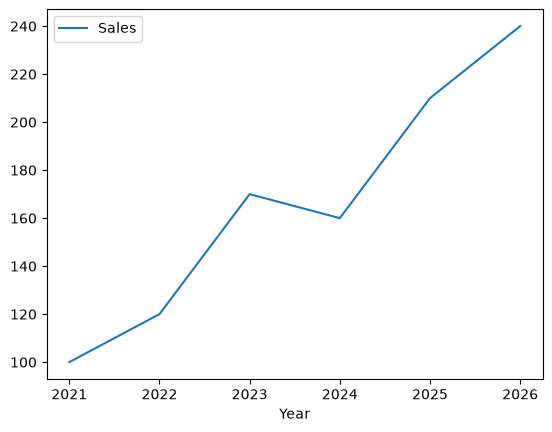

In [10]:
df1.plot(x='Year', y='Sales', kind='line')
plt.show()

## Another Simple Example

In this example, we demonstrate how to plot more than one line in the same figure.

We create data showing number of units sold per month for two products, $A$ and $B$..

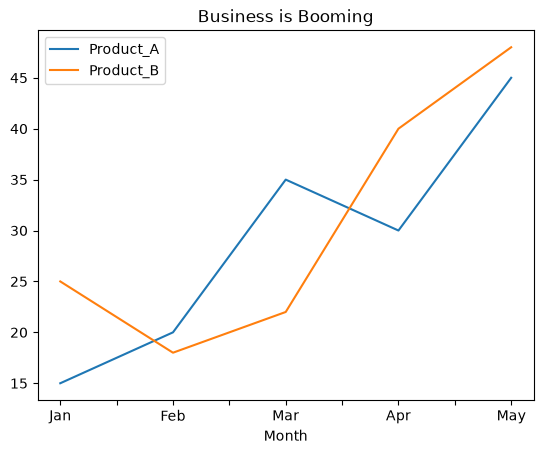

In [11]:
data = {
    'Month': ['Jan', 'Feb', 'Mar', 'Apr', 'May'],
    'Product_A': [15, 20, 35, 30, 45],
    'Product_B': [25, 18, 22, 40, 48]
}
df2 = pd.DataFrame(data)

df2.plot.line(x='Month', y=['Product_A', 'Product_B'], title="Business is Booming")
plt.show()

:::{note}

It makes sense to show multiple lines in the same figure if their associated features have the same domain. 

In the example both lines represent prices of products.

:::

We can show the two lines on separate axes with the `subplots` argument set to `True`.

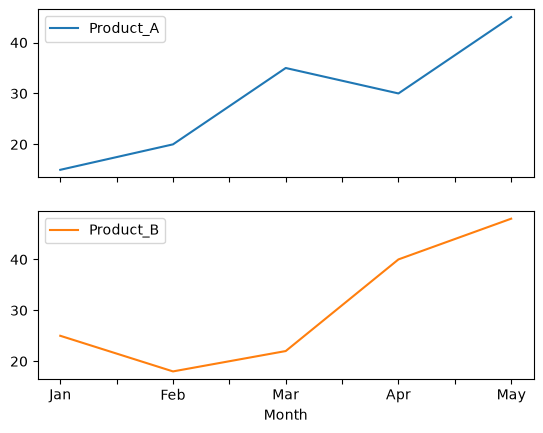

In [12]:
df2.plot.line(x='Month', y=['Product_A', 'Product_B'], subplots=True)
plt.show()

## Using Pandas Indexes

As we saw earlier, Pandas defaults to showing the index of a data frame on the x axis if x is left unspecified.

Here we set `Month` to the index, since the values are uniqure over the observations.

Then, since the remaining non-index features are related, we don't need to specify those, either. Pandas assumes you want to show them all.

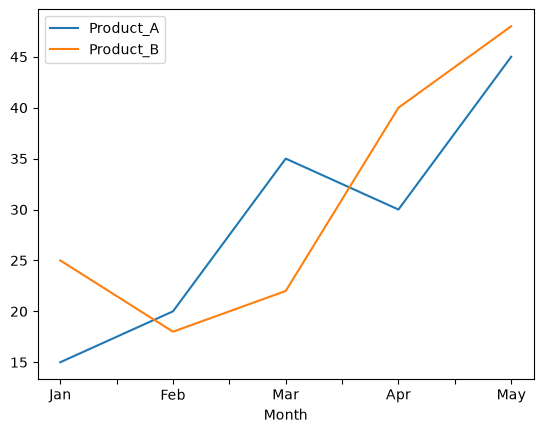

In [13]:
df3 = df2.set_index('Month')
df3.plot()
plt.show()

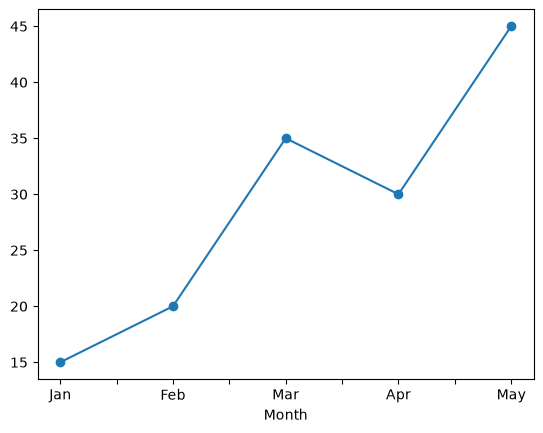

In [14]:
df3.Product_A.plot.line(style='-o')
plt.show()

We can set the attributes of multiple lines by passing lists to the arguments.

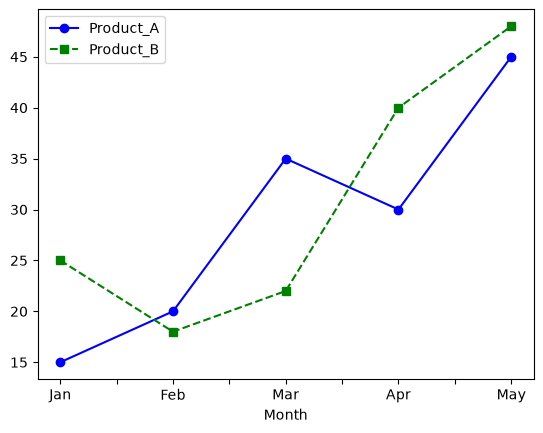

In [15]:
df3.plot.line(style=['o-', 's--'], color=['blue', 'green'])
plt.show()

Note that these data _can_ be visualized with a bar chart. 

However, they are better visualized with a line graph to show the trend of the data over the numeric sequence.

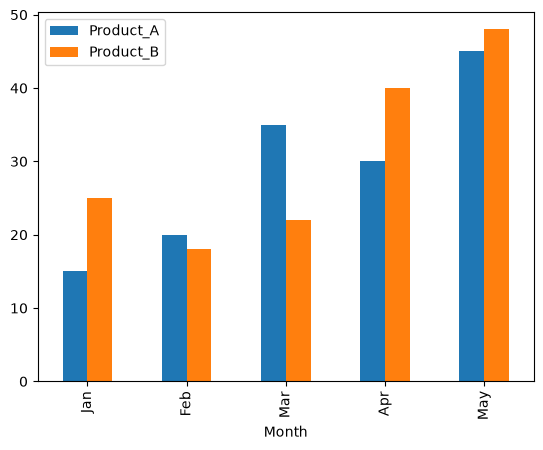

In [16]:
df3.plot.bar()
plt.show()

:::{admonition} Question

What differences do you notice in how the axes are represented?

:::

:::{admonition} Answer
:class: dropdown

- The years on the x axis are treated as categories
- The y axis is not clipped but begins with $0$

:::

## A More Complex Example

Arbuthnot's data describes male and female births for London from 1629-1710.

John Arbuthnot (1710) used these time series data to carry out the first known significance test. During every one of the 81 years, there were more male christenings (births) than female christenings. As Arbuthnot wondered, we might also wonder if this could be due to chance, or whether it meant the birth ratio was not actually 1:1.

- Year:    The year, ranging from 1629 to 1710.
- Males:   Number of male christenings (births).
- Females: Number of female christenings (births).
- Plague:  Number of deaths from the Plague.
- Mortality: Total deaths (all causes combined) for that calendar year.
- Ratio:   Ration of Males to Females.
- Total:  The total number of births scaled in thousands (000s).

In [46]:
data_url = "https://vincentarelbundock.github.io/Rdatasets/csv/HistData/Arbuthnot.csv"
dfx = pd.read_csv(data_url)
dfx = dfx.set_index('Year')
dfx = dfx.drop("rownames", axis=1)
dfx.head()

,Males,Females,Plague,Mortality,Ratio,Total
Year,,,,,,
1629,5218,4683,0,8771,1.114243,9.901
1630,4858,4457,1317,10554,1.089971,9.315
1631,4422,4102,274,8562,1.078011,8.524
1632,4994,4590,8,9535,1.088017,9.584
1633,5158,4839,0,8393,1.065923,9.997


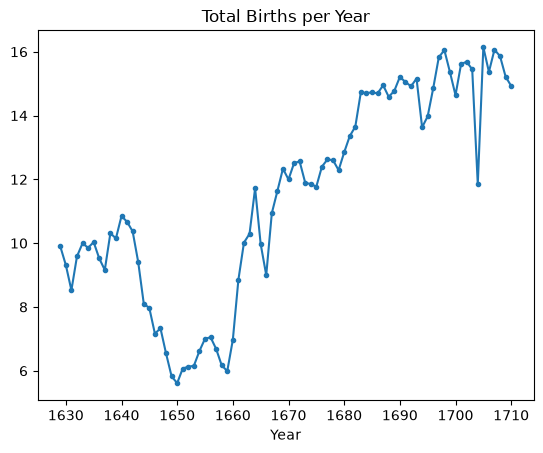

In [47]:
dfx.plot(y='Total', style='.-', legend=False, title="Total Births per Year")
plt.show()

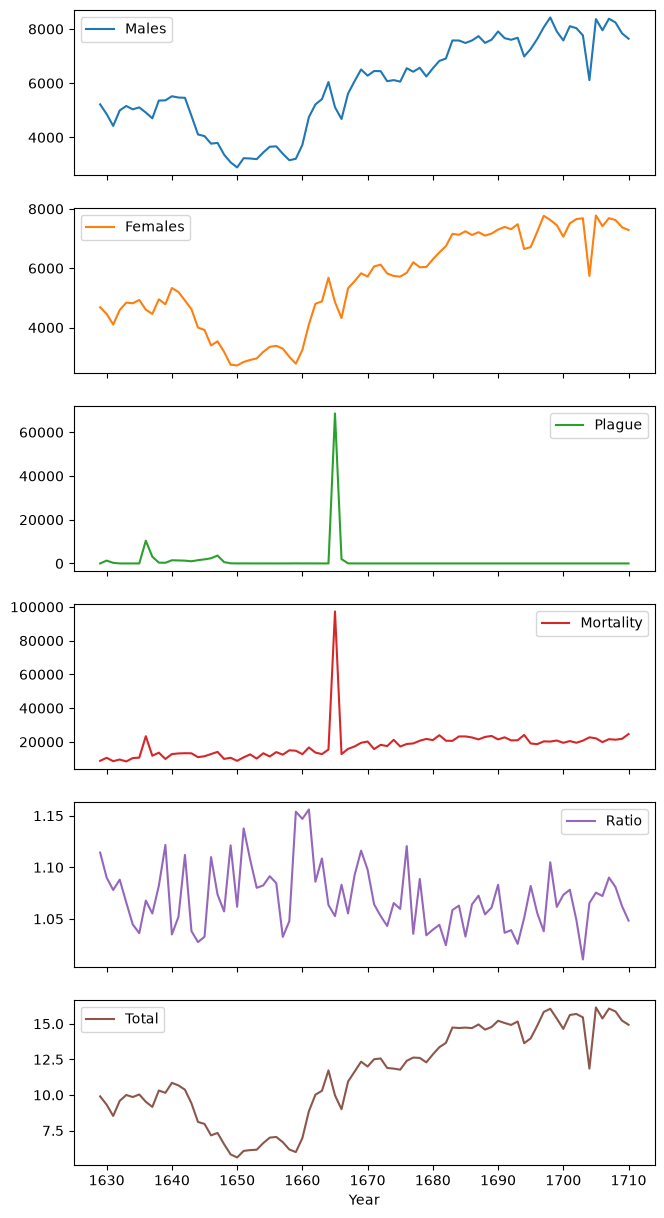

In [48]:
dfx.plot(subplots=True, figsize=(7.5,15))
plt.show()

In [49]:
dfx.describe().T

,count,mean,std,min,25%,50%,75%,max
Males,82.0,5907.097561,1652.753629,2890.000000,4759.250000,6073.000000,7576.50000,8426.000000
Females,82.0,5534.646341,1592.137490,2722.000000,4457.000000,5718.000000,7150.25000,7779.000000
Plague,82.0,1240.695122,7644.999175,0.000000,0.000000,3.000000,22.25000,68596.000000
Mortality,82.0,17816.475610,10105.994029,8393.000000,12738.750000,17867.000000,21029.50000,97306.000000
Ratio,82.0,1.070748,0.031254,1.010673,1.048469,1.064704,1.08751,1.156075
Total,82.0,11.441744,3.241638,5.612000,9.198750,11.813000,14.72300,16.145000


## Showing Two Y-Axis Scales on the Same Axis

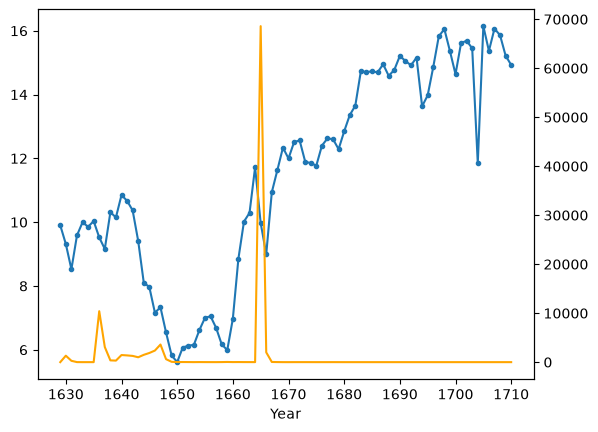

In [50]:
ax = dfx.Total.plot(style='.-')
ax2 = ax.twinx()
dfx.Plague.plot(ax=ax2, color='orange', style='-')
plt.show()

In [24]:
dfx.Mortality.idxmax()

1665

## Plotting Functions

Line charts are also useful for plotting classicial mathematical functions, where $y$ is a function of $x$, i.e. $y = f(x)$.

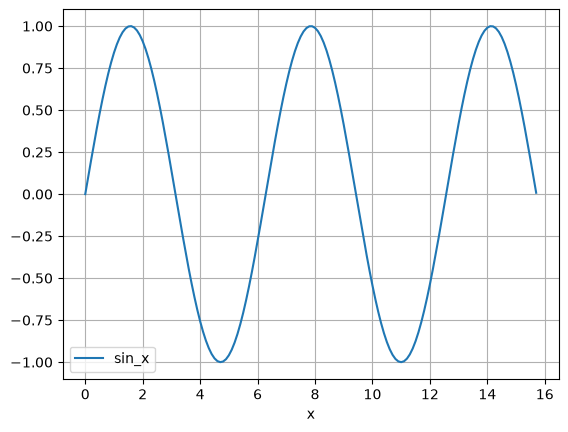

In [25]:
df = pd.DataFrame()
df['x'] = np.arange(0, 5 * np.pi, 0.1)
df['sin_x'] = np.sin(df.x)
df.plot(x='x', y='sin_x')
plt.grid(True)
plt.show()

In [30]:
df['cos_x'] = np.cos(df.x)
df.head()

,x,sin_x,cos_x
0,0.0,0.000000,1.000000
1,0.1,0.099833,0.995004
2,0.2,0.198669,0.980067
3,0.3,0.295520,0.955336
4,0.4,0.389418,0.921061


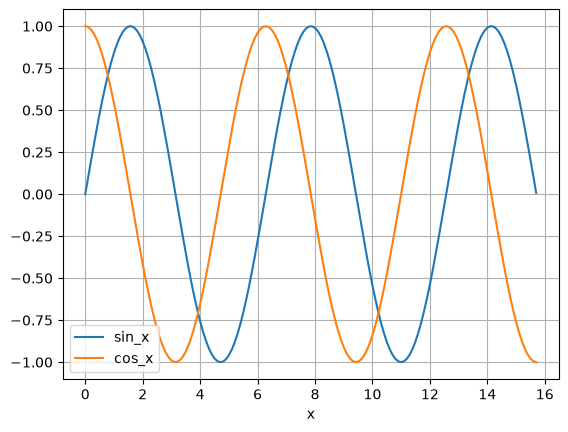

In [27]:
df.plot(x='x', y=['sin_x','cos_x'])
plt.grid()
plt.show()

## 
Plotting Processes

Line graphs are good at showing processes.

Kinds of process:

- linear
- cyclical
- exponential
- volatile
- multi-Variable (comparative)

See [Google AI](https://www.google.com/search?smstk=ChhnYTNOczVZam5PbGxOMndRTlM5Y2dSUT0QBA%3D%3D&smstidx=0&q=I+would+like+to+teach+visualization+of+line+graphs+by+showing+the+different+kinds+of+processes+that+they+can+display&udm=50&csuir=1&aep=34&kgs=27e705e751257e2a&shem=epsd1%2Crimspwouoe&shndl=37&shmd=H4sIAAAAAAAA_3WPPU4EMQxGWSq0DRIllUWJxIRtKBAX4BSRJ_Ek1uZPcYbZodo70XAGTkVGggrR2u_5-7z_uNy3V1jyHCwEPhK0DI3QeHhjmTHwOzbOCfLU14nAVSxeYFxBfF44OWiewPI0UaXU4MjJykaXmg2JkHQA20atYDB1VErA9fbFt1bkWallWQYnrceYweSohLAa_9D9mBVy1OKxkm5-jmNCDkNJ7u7m13Y5u0ADsrq_OJ2vz7vPq6-d_u82R3QkaqyYbO_-Yzvdv7Lc66vD6c9Mdz9ZrFYfnh5t2eK_AV9CfbY2AQAA&shmds=v1_ARwrE23f8e36MRAhIRRyCNGX2IZ34ok31LBB0pjdKmyZfeelPw&source=sh%2Fx%2Faio%2Fm1%2F4&mtid=69M-avvuPPGnptQPxcv34A8)